**Importante:** para rodar esse notebook é necessário subir dois csv's disponíveis na pasta: data/arquivos_modelos:
* idhm_gold.csv
* pib_renda_gold.csv

In [ ]:
# Instalação de todas as dependências
!pip install scikit-learn pandas numpy optuna xgboost scipy shap matplotlib seaborn s3fs pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.0/102.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 26.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.12.0
    Uninstalling fsspec-2025.12.0:
      Successfully uninstalled fsspec-2025.12.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.12.0 requires fsspec==2025.12.0, but you have fsspec 2026.7.0 which is incompatible.
datasets 4.8.5 requires fsspec[http]<=2026.2.0,>=2023.1.0, but you have fsspec 2026.7.0 which is incompatible.


In [ ]:
 # ======================================
# IMPORTANDO BIBLIOTECAS
# ======================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Visualização da árvore
from sklearn.tree import plot_tree

# Normalização
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

#Métricas de classificação
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

#Feature selection
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif
from sklearn.feature_selection import RFECV

#Validação
from sklearn.model_selection import learning_curve
from sklearn.model_selection import validation_curve
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from scipy.stats import ks_2samp

#Validação cruzada
from sklearn.datasets import make_classification
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, cross_val_score
)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import optuna
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint, loguniform

#SHAP
import shap

#Imputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer



# **Treino do modelo e métricas de validação**

In [ ]:
# ======================================
# CONECTANDO NA GOLD (BASE DE DADOS)
# ======================================

# VARIAVEIS
s3_path_comparativo_metas_resultados = "s3://fiap-datalake-tech-public/gold/comparativo_metas_resultados/"


#ACESSO
dados = pd.read_parquet(
    s3_path_comparativo_metas_resultados,
    engine="pyarrow",
    storage_options={"anon": True}
)

dados.head(n=5)


,ano,sigla_uf,id_municipio,nome_municipio,total_avaliados,taxa_alfabetizacao_real,meta_ano,desvio_meta,status_meta,_gold_processed_at,_analytics_version
0,2023,RO,1100072,Corumbiara,119,59.66,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3
1,2023,RO,1100122,Ji-Paraná,1496,70.52,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3
2,2023,RO,1101450,Parecis,55,56.36,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3
3,2023,AM,1300631,Beruri,243,89.71,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3
4,2023,AM,1301605,Fonte Boa,380,38.95,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3


In [ ]:
pib_renda = pd.read_csv('pib_renda_gold.csv')

# # Filtra apenas colunas necessárias e remove duplicatas de id_municipio
pib_renda_unico = pib_renda[[
    'id_municipio',
    'pib_per_capita_R$',
    'renda_media_per_capita_R$',
    'densidade_demografica'
]].drop_duplicates(subset=['id_municipio'])

# Merge sem gerar linhas duplicadas
dados_mais_pib_renda = dados.merge(
    pib_renda_unico,
    on='id_municipio',
    how='left'
)
dados_mais_pib_renda.head()

,ano,sigla_uf,id_municipio,nome_municipio,total_avaliados,taxa_alfabetizacao_real,meta_ano,desvio_meta,status_meta,_gold_processed_at,_analytics_version,pib_per_capita_R$,renda_media_per_capita_R$,densidade_demografica
0,2023,RO,1100072,Corumbiara,119,59.66,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,67914.967346,402.15,2.451961
1,2023,RO,1100122,Ji-Paraná,1496,70.52,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,47065.679747,743.35,17.942874
2,2023,RO,1101450,Parecis,55,56.36,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,49413.928396,343.73,1.599843
3,2023,AM,1300631,Beruri,243,89.71,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,12680.615355,193.40,1.183025
4,2023,AM,1301605,Fonte Boa,380,38.95,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,12604.111612,200.40,2.116989


In [ ]:
idhm = pd.read_csv('idhm_gold.csv')

# Merge sem gerar linhas duplicadas
dados_mais_pib_renda_idhm = dados_mais_pib_renda.merge(
    idhm[['id_municipio', 'idhm']],
    on='id_municipio',
    how='left'
)
dados_mais_pib_renda_idhm.head()

,ano,sigla_uf,id_municipio,nome_municipio,total_avaliados,taxa_alfabetizacao_real,meta_ano,desvio_meta,status_meta,_gold_processed_at,_analytics_version,pib_per_capita_R$,renda_media_per_capita_R$,densidade_demografica,idhm
0,2023,RO,1100072,Corumbiara,119,59.66,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,67914.967346,402.15,2.451961,0.613
1,2023,RO,1100122,Ji-Paraná,1496,70.52,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,47065.679747,743.35,17.942874,0.714
2,2023,RO,1101450,Parecis,55,56.36,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,49413.928396,343.73,1.599843,0.617
3,2023,AM,1300631,Beruri,243,89.71,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,12680.615355,193.40,1.183025,0.506
4,2023,AM,1301605,Fonte Boa,380,38.95,NaN,NaN,Sem Meta Definida,2026-07-14 21:33:01.491955,v3.0_spark_native_s3,12604.111612,200.40,2.116989,0.530


In [ ]:
# ============================================================================================
# 1. DEFININDO X e y E DIVISÃO TREINO E TESTE
#    Temporal: 2024 -> Treino | 2025 -> Teste
# ============================================================================================

# Antes de qualquer transformação relacionada ao modelo, garantimos a ordenação temporal por município.

dados_modelo = dados_mais_pib_renda_idhm.sort_values(
    by=["id_municipio", "ano"]
).reset_index(drop=True)


# ============================================================================================
# 2. FEATURE EXTRACTION
# ============================================================================================
# #Para chegarmos no Status Meta (com as classes "atingiu" ou "não atingiu") utilizamos o desvio, se era >=0 o municipio atingiu, se não, não atingiu a meta na Gold.
# O feature extraction ajudou a não ter no modelo duas features que não agregariam (meta_ano e desvio_ano) e que poderiam gerar associações espúrias e aumentar a dimensionalidade.

# Para chegarmos ao Status Meta, utilizamos as classes:
# "Abaixo da Meta" e "Atingiu a Meta".
#
# 2023 possui apenas "Sem Meta Definida", portanto não participa
# do treinamento do modelo. Além disso, gera muito resíduo na nossa base na etapa de KNN dos lags. Quando incluído, apresentava um F1 score de 0.16 com apenas 211 ocorrências (support), portanto, sem serventia para o modelo.

status_desejados = [
    "Abaixo da Meta",
    "Atingiu a Meta"
]

dados_modelo = dados_modelo[
    dados_modelo["status_meta"].isin(status_desejados)
].copy()


# ============================================================================================
# 3. DIVISÃO TEMPORAL (Treino e Teste)
# ============================================================================================

# Separação baseada no ano ANTES das transformações específicas
# de treinamento.

dados_treino = dados_modelo[
    dados_modelo["ano"] == 2024
].copy()

dados_teste = dados_modelo[
    dados_modelo["ano"] == 2025
].copy()


# Salvar metadados dos municípios de 2025 para a tabela final de comparação.

df_resultado_2025 = dados_teste[
    [
        "id_municipio",
        "nome_municipio",
        "sigla_uf",
        "status_meta"
    ]
].copy()


# ============================================================================================
# 4. FEATURE ENGINEERING
# ============================================================================================

# IMPORTANTE:
# Os features temporais precisam utilizar somente informações anteriores ao ano que está sendo previsto.
# Como o objetivo é prever 2025 utilizando 2024 como referência, calculamos os features temporais na base completa, mas sempre utilizando shift(1), impedindo que o próprio ano corrente entre no cálculo.
# Como estamos trabalhando com dados de 2023, 2024 e 2025, vamos trabalhar com séries temporais. Como nossa amostragem é de apenas 3 anos, ao tentar decompor para séries tremporais nosso dataset nos
# deparamos com a dificuldade de aplicar um período ideal na biblioteca de statsmodel, para aplicar 2, teríamos que ter pelo menos 4 observações, e nós extraímos a média por ano de 3 anos, ou seja, nossa amostragem era insuficiente.
# Para o ADF também tivemos problemas por conta da amostragem pequena também.
# Com isso, como nosso dataframe possui dados temporais e o algoritmo não tem a capacidade de interpretá-lo de maneira sequencial (temporal), vamos utilizar séries temporais para utilizá-los
#corretamente no nosso modelo, de forma que não tenha data leakege, onde o modelo poderia prever o "passado utilizando o futuro", com dados de 2025 na previsão de 2025, por exemplo.


dados_modelo = dados_modelo.sort_values(
    by=["id_municipio", "ano"]
).reset_index(drop=True)


# Lag do ano anterior
dados_modelo["lag_1"] = (
    dados_modelo
    .groupby("id_municipio")["taxa_alfabetizacao_real"]
    .shift(1)
)


# Diferença em relação ao ano anterior
dados_modelo["diff_1"] = (
    dados_modelo
    .groupby("id_municipio")["taxa_alfabetizacao_real"]
    .diff(1)
)


# Média móvel dos 2 anos anteriores
# shift(1) impede que o valor do próprio ano entre no cálculo.
dados_modelo["rolling_mean_2"] = (
    dados_modelo
    .groupby("id_municipio")["taxa_alfabetizacao_real"]
    .transform(
        lambda x: x.shift(1).rolling(
            2,
            min_periods=1
        ).mean()
    )
)


# ============================================================================================
# 5. FEATURE EXTRACTION / AGREGAÇÃO POR UF
# ============================================================================================

# Criar agregação por UF para ajudar no feature engineering já que a adição de taxa_alfabetizacao_real gera data leakage
# A média estadual deve ser calculada utilizando somente informações disponíveis até o período de previsão.
# Para previsão de 2025, utilizamos a média de 2024 por UF.

media_alfa_uf_treino = (
    dados_modelo[dados_modelo["ano"] == 2024]
    .groupby("sigla_uf")["taxa_alfabetizacao_real"]
    .mean()
    .rename("media_alfa_uf")
)


# Aplicar a média de 2024 no treino

dados_treino = dados_modelo[
    dados_modelo["ano"] == 2024
].copy()

dados_treino = dados_treino.merge(
    media_alfa_uf_treino,
    on="sigla_uf",
    how="left"
)


# Aplicar a mesma informação no teste.
# NÃO recalculamos a média usando 2025.

dados_teste = dados_modelo[
    dados_modelo["ano"] == 2025
].copy()

dados_teste = dados_teste.merge(
    media_alfa_uf_treino,
    on="sigla_uf",
    how="left"
)


# ============================================================================================
# 6. DEFINIÇÃO DO X E y
# ============================================================================================

colunas_X = [
    "ano",
    "lag_1",
    "diff_1",
    "rolling_mean_2",
    "total_avaliados",
    "media_alfa_uf",
    "sigla_uf",
    "idhm",
    "renda_media_per_capita_R$",
    "pib_per_capita_R$",
    "densidade_demografica",
]


X_train = dados_treino[colunas_X].copy()
X_test = dados_teste[colunas_X].copy()

y_train = dados_treino["status_meta"].copy()
y_test = dados_teste["status_meta"].copy()


# ============================================================================================
# 7. REMOÇÃO DA COLUNA ANO
# ============================================================================================

X_train = X_train.drop(
    columns=["ano"]
).reset_index(drop=True)

X_test = X_test.drop(
    columns=["ano"]
).reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)


# ============================================================================================
# 8. FEATURE ENCODING — X
# ============================================================================================

# One-Hot Encoding do estado.

X_train = pd.get_dummies(
    X_train,
    columns=["sigla_uf"],
    drop_first=True,
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=["sigla_uf"],
    drop_first=True,
    dtype=int
)


# Garantir exatamente as mesmas colunas no treino e teste.
# Isso evita problemas caso alguma UF esteja presente em um
# conjunto e ausente no outro.

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)


# ============================================================================================
# 9. IMPUTER TRANSFORMER
# ============================================================================================

# Aplicamos o imputer APENAS depois da divisão temporal.
#
# O fit é feito exclusivamente no treino.
# O teste apenas recebe o transform aprendido no treino.

colunas_para_imputar = [
    "lag_1",
    "diff_1",
    "rolling_mean_2"
]


knn_imputer = KNNImputer(
    n_neighbors=5,
    weights="uniform",
    keep_empty_features=True
)


# Guarda as colunas originais

colunas_X = X_train.columns


# FIT somente no treino

X_train_imputed = knn_imputer.fit_transform(
    X_train
)


# TRANSFORM no teste

X_test_imputed = knn_imputer.transform(
    X_test
)


# Reconstruir DataFrames

X_train = pd.DataFrame(
    X_train_imputed,
    columns=colunas_X
)

X_test = pd.DataFrame(
    X_test_imputed,
    columns=colunas_X
)


# ============================================================================================
# 10. FEATURE ENCODING — y
# ============================================================================================

le_y = LabelEncoder()

# FIT somente no treino

y_train_encoded = le_y.fit_transform(
    y_train
)

# TESTE apenas recebe o mapeamento aprendido

y_test_encoded = le_y.transform(
    y_test
)


# ============================================================================================
# 11. ESCALONAMENTO
# ============================================================================================

#Utilizamos o StandardScale (desvio padrão) porque é indicado para Regressão Logística, já que não temos tantos outliers no conjunto de dados para justificar o uso do Robust Scaling

scaler = StandardScaler()

# FIT somente no treino

X_train_scaled = scaler.fit_transform(
    X_train
)

# TRANSFORM no teste

X_test_scaled = scaler.transform(
    X_test
)


# ============================================================================================
# 12. FEATURE SELECTION — SELECT KBEST
# ============================================================================================
# Mutual Information (escolhida porque é mais versátil, permitindo qualquer feature categórica ou não.
# Apesar do dataset não ser grande (não possui milhares de observações), a seleção de features vai nos ajudar na interpretabilidade)
selector = SelectKBest(
    mutual_info_classif,
    k=10
)


# FIT somente no treino
X_train_selected = selector.fit_transform(
    X_train_scaled,
    y_train_encoded
)


# TESTE apenas recebe a seleção aprendida

X_test_selected = selector.transform(
    X_test_scaled
)


# Verificar features selecionadas
selected_names = X_train.columns[
    selector.get_support()
]

print(
    "Features selecionadas (Mutual Info):",
    selected_names.tolist()
)

print(
    "Treino:",
    X_train_selected.shape
)

print(
    "Teste:",
    X_test_selected.shape
)


Features selecionadas (Mutual Info): ['media_alfa_uf', 'sigla_uf_BA', 'sigla_uf_CE', 'sigla_uf_ES', 'sigla_uf_GO', 'sigla_uf_MA', 'sigla_uf_MG', 'sigla_uf_RO', 'sigla_uf_RS', 'sigla_uf_SC']
Treino: (5233, 10)
Teste: (5346, 10)


Chegamos a utilizar o wrapper RFECV que encontra o ponto ótimo via validação cruzada, teve uma ótima acurácia também: 0.8492, porém, demorou muito mais do que o selectkbest. Ou seja, tem um custo computacional maior.

In [ ]:
# # =============================================================================
# # TREINAMENTO COM REGRESSÃO LOGÍSTICA (OTIMIZADO COM GRID SEARCH)
# # =============================================================================
# 1. Definir a estratégia de validação cruzada temporal
tscv = TimeSeriesSplit(n_splits=4)

# 2. Definir o grid de parâmetros
param_grid = {
    'C': [0.00001, 0.0001, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02],
    'penalty': ['l1'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [3000]
}

# 3. Instanciar o modelo
modelo = LogisticRegression(class_weight='balanced', random_state=42)

# 4. Instanciar o GridSearchCV
grid_search = GridSearchCV(
    estimator=modelo,
    param_grid=param_grid,
    cv=tscv, #Para série temporal
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

# 5. Treinar nos dados de treino
grid_search.fit(X_train_selected, y_train_encoded)

# 6. Exibir os melhores resultados
print(f"Melhor score (Validação Cruzada): {grid_search.best_score_:.4f}")
print("Melhores Hiperparâmetros:", grid_search.best_params_)

Fitting 4 folds for each of 16 candidates, totalling 64 fits
Melhor score (Validação Cruzada): 0.5054
Melhores Hiperparâmetros: {'C': 0.01, 'max_iter': 3000, 'penalty': 'l1', 'solver': 'liblinear'}


Usamos regressão logística porque inicialmente pensamos na possibilidade de usar probabilidade (qual a probabilidade de que esse municipio atinja a meta em 2026, 2027, 2028, 2029 e 2030?), de forma que a explicabilidade fosse mais facilitada.

Como nosso dataset é pequeno, e com pouca dimensionalidade, optamos pro um modelo que utiliza poucos recursos computacionais.

Além disso, optamos por Grid Search CV por ter um custo mais controlado.

=== COMPARAÇÃO REALIDADE VS ESTIMADO (2025) ===
           nome_municipio sigla_uf     status_meta status_meta_estimado  \
2   Alta Floresta D'Oeste       RO  Atingiu a Meta       Atingiu a Meta   
5               Ariquemes       RO  Atingiu a Meta       Atingiu a Meta   
8                  Cabixi       RO  Atingiu a Meta       Atingiu a Meta   
11                 Cacoal       RO  Atingiu a Meta       Atingiu a Meta   
14             Cerejeiras       RO  Atingiu a Meta       Atingiu a Meta   
17      Colorado do Oeste       RO  Atingiu a Meta       Atingiu a Meta   
20             Corumbiara       RO  Atingiu a Meta       Atingiu a Meta   
23          Costa Marques       RO  Abaixo da Meta       Atingiu a Meta   
26        Espigão D'Oeste       RO  Atingiu a Meta       Atingiu a Meta   
29          Guajará-Mirim       RO  Atingiu a Meta       Atingiu a Meta   

    probabilidade_confianca  acertou  
2                  0.530197     True  
5                  0.530197     True  
8        

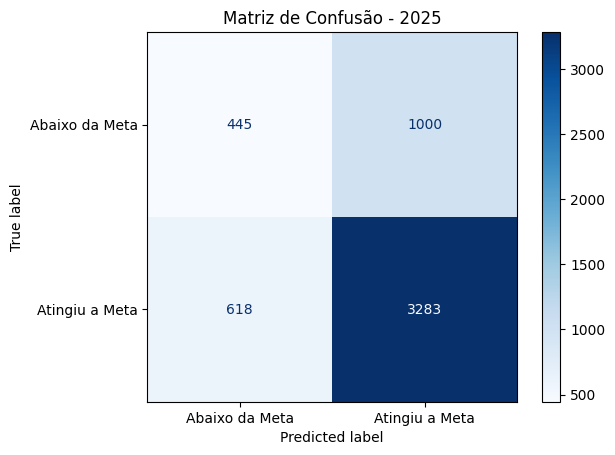

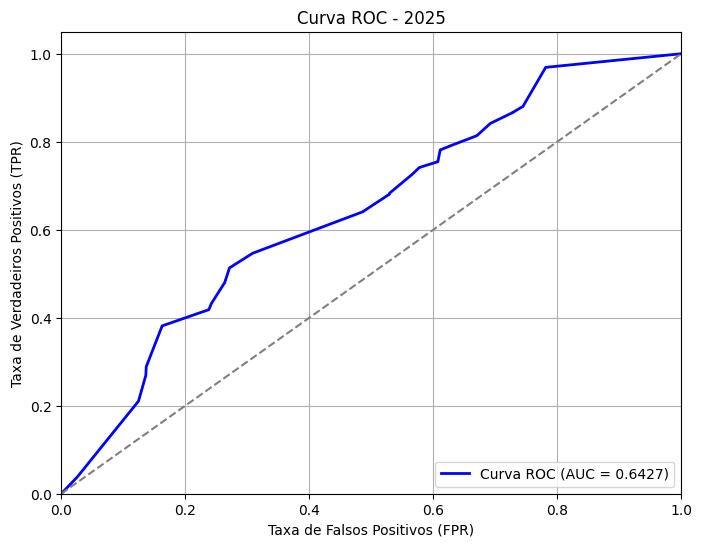

ROC AUC Score Geral: 0.6427


In [ ]:
# ===============================================================
# MÉTRICAS DE AVALIAÇÃO (MODELO OTIMIZADO GRID SEARCH)
# ===============================================================

# 1. Obter o melhor modelo ajustado no RandomizedSearch
melhor_modelo = grid_search.best_estimator_

# 2. Obter probabilidades no conjunto de teste (2025)
y_prob_matrix = melhor_modelo.predict_proba(X_test_selected)

# 3. Probabilidade da Classe 1 (Positiva)
y_prob_pos = y_prob_matrix[:, 1]

# 4. Aplicação do Threshold porque tem desbalanceamento de classes
threshold = 0.40
y_pred_encoded = (y_prob_pos >= threshold).astype(int)

# 5. Decodificar rótulos previstos para texto ('Atingiu a Meta', 'Abaixo da Meta', etc.)
df_resultado_2025["status_meta_estimado"] = le_y.inverse_transform(y_pred_encoded)

# 6. Adicionar a probabilidade de confiança do modelo (Maior valor entre as classes)
df_resultado_2025["probabilidade_confianca"] = y_prob_matrix.max(axis=1)

# 7. Flag de acerto
df_resultado_2025["acertou"] = (
    df_resultado_2025["status_meta"] == df_resultado_2025["status_meta_estimado"]
)

# Visualizar comparação dos primeiros 10 municípios
print("=== COMPARAÇÃO REALIDADE VS ESTIMADO (2025) ===")
print(
    df_resultado_2025[
        [
            "nome_municipio",
            "sigla_uf",
            "status_meta",
            "status_meta_estimado",
            "probabilidade_confianca",
            "acertou",
        ]
    ].head(10)
)

# Taxa global de acertos no ano de 2025
acuracia_2025 = df_resultado_2025["acertou"].mean()
print(f"\nAcurácia geral do modelo para 2025: {acuracia_2025:.2%}\n")



# AVALIAÇÃO DAS MÉTRICAS DE CLASSIFICAÇÃO

# 1. Métricas gerais resumidas (Média Ponderada)
accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
precision_macro = precision_score(y_test_encoded, y_pred_encoded, average='macro')
recall_macro  = recall_score(y_test_encoded, y_pred_encoded, average='macro')
f1_macro  = f1_score(y_test_encoded, y_pred_encoded, average='macro')
#average=macro porque as classes são desbalanceadas

print(f"Acurácia Geral:         {accuracy:.4f}")
print(f"Precisão:    {precision_macro:.4f}")
print(f"Recall:      {recall_macro:.4f}")
print(f"F1-Score:    {f1_macro:.4f}\n")

# 2. Visão detalhada por classe
print("--- Relatório Completo por Classe ---")
print(classification_report(y_test_encoded, y_pred_encoded))

# 3. Matriz de Confusão
matriz = confusion_matrix(y_test_encoded, y_pred_encoded)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=le_y.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão - 2025")
plt.show()

# 4. Curva ROC (Binária para a classe positiva)
auc_score_geral = roc_auc_score(y_test_encoded, y_prob_pos)
fpr, tpr, thresholds_roc = roc_curve(y_test_encoded, y_prob_pos)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # Linha de aleatoriedade

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - 2025')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f'ROC AUC Score Geral: {auc_score_geral:.4f}')


Summary Plot (Beeswarm) - Valores Originais


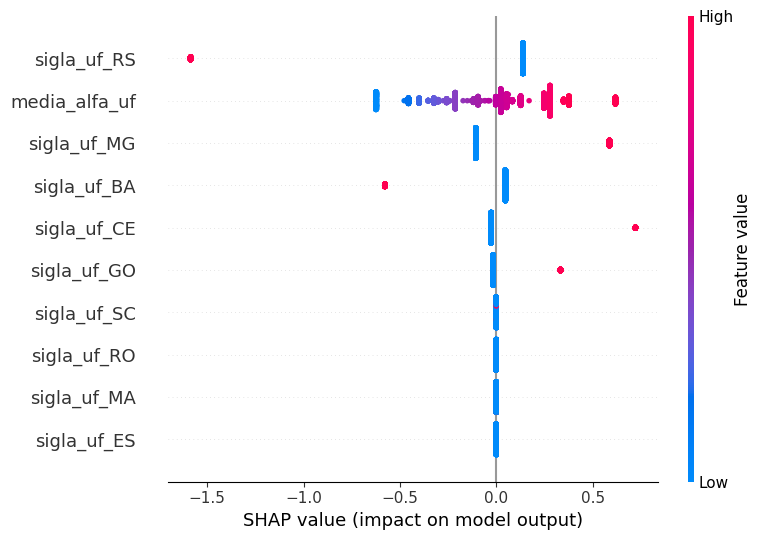

Summary Plot (Bar)


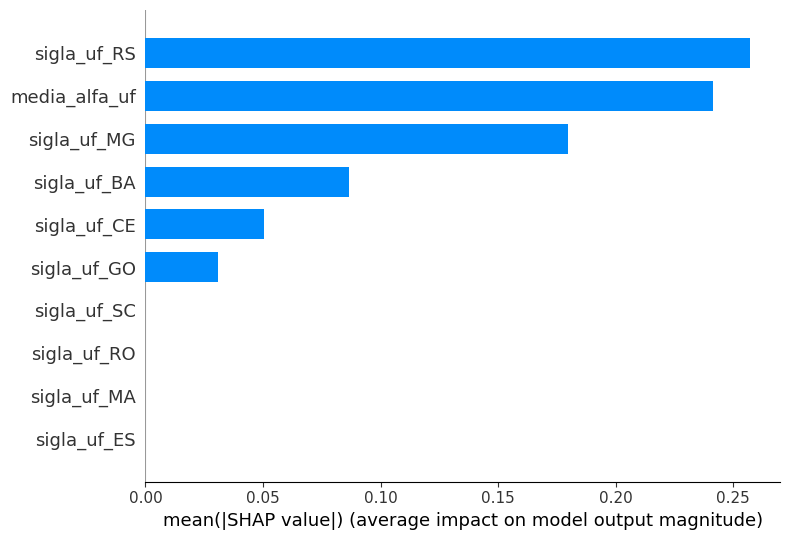

Dependence plots - Valores Originais


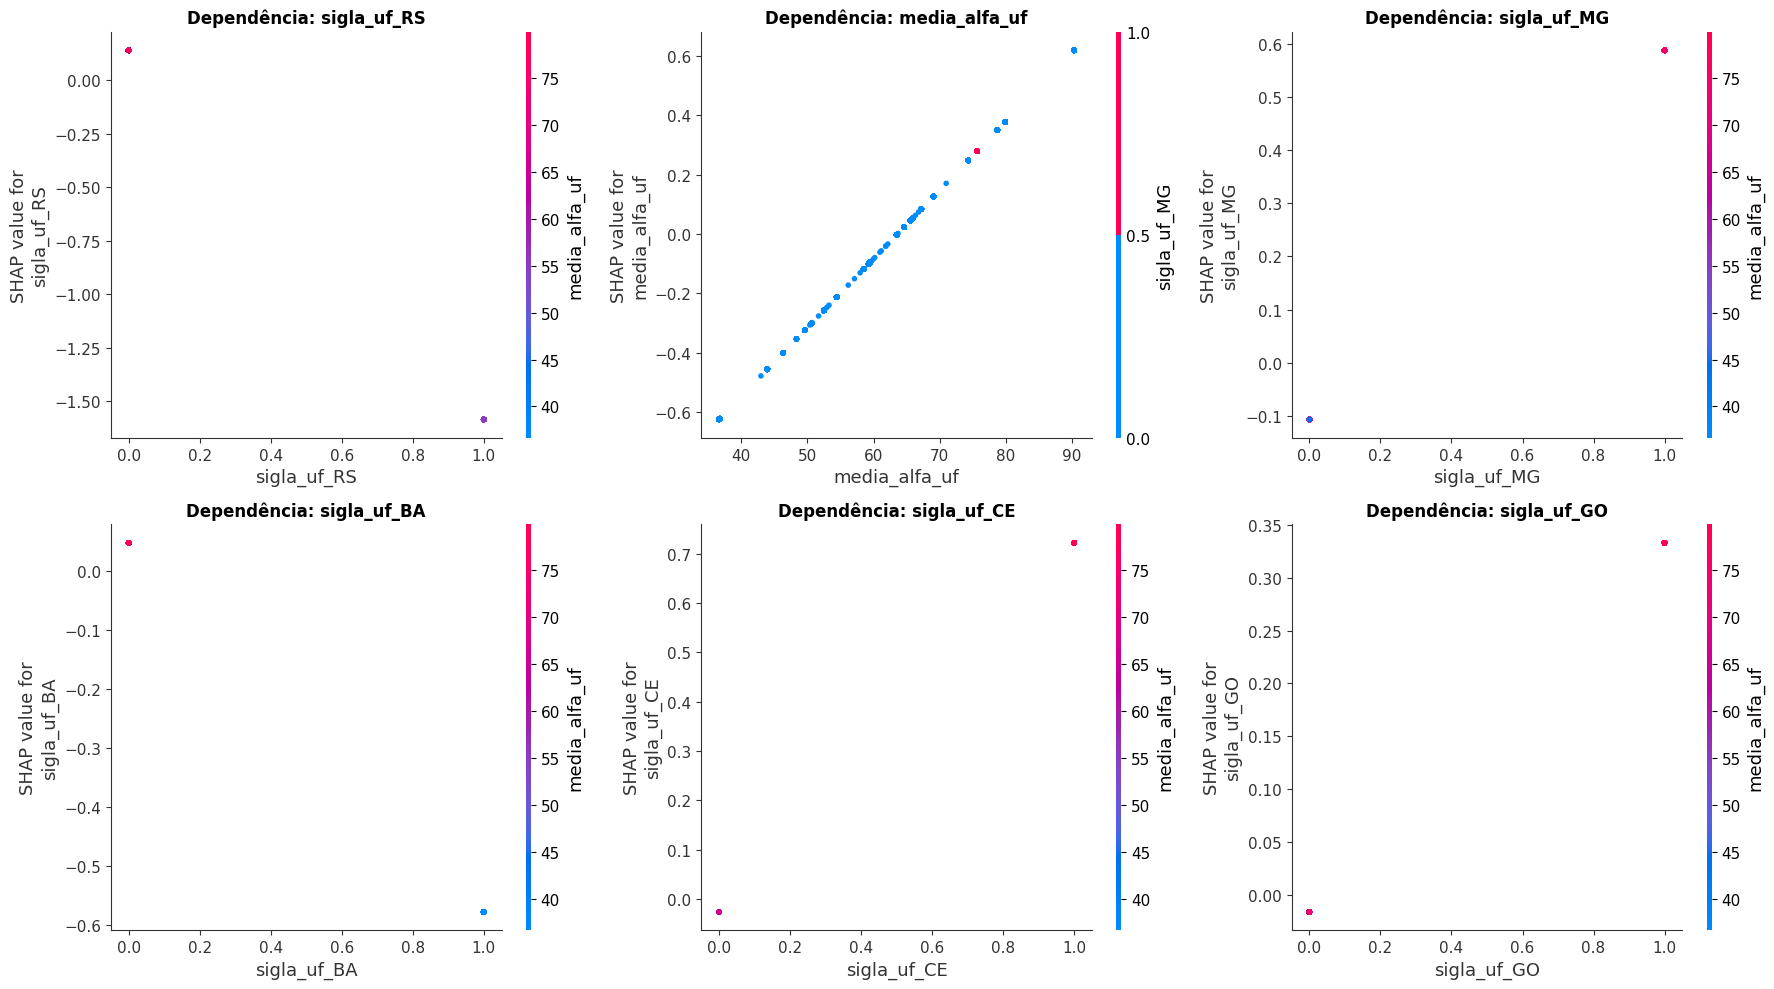

Waterfall plots - Valores Originais


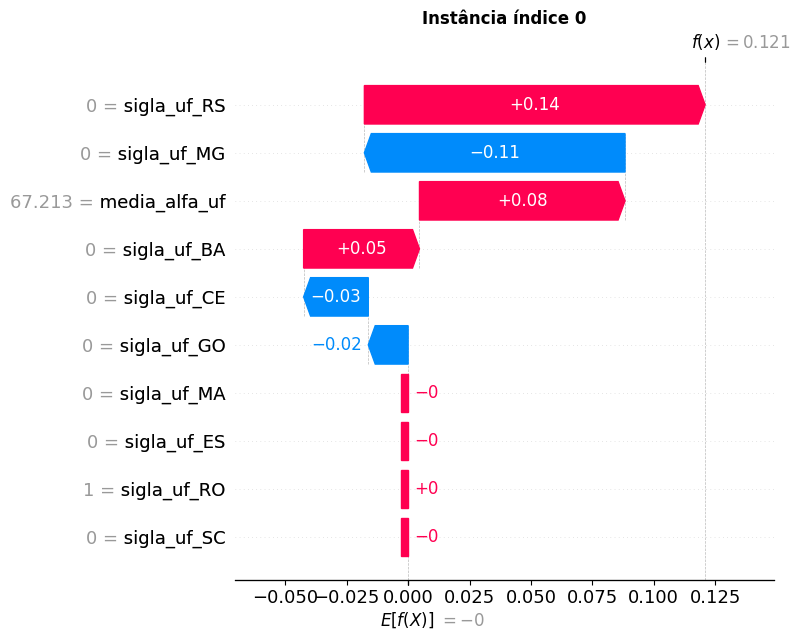

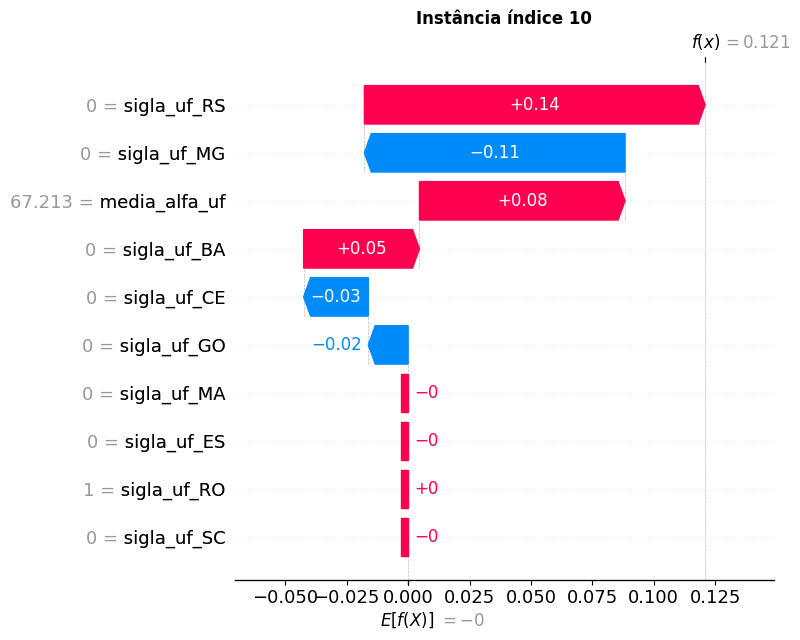

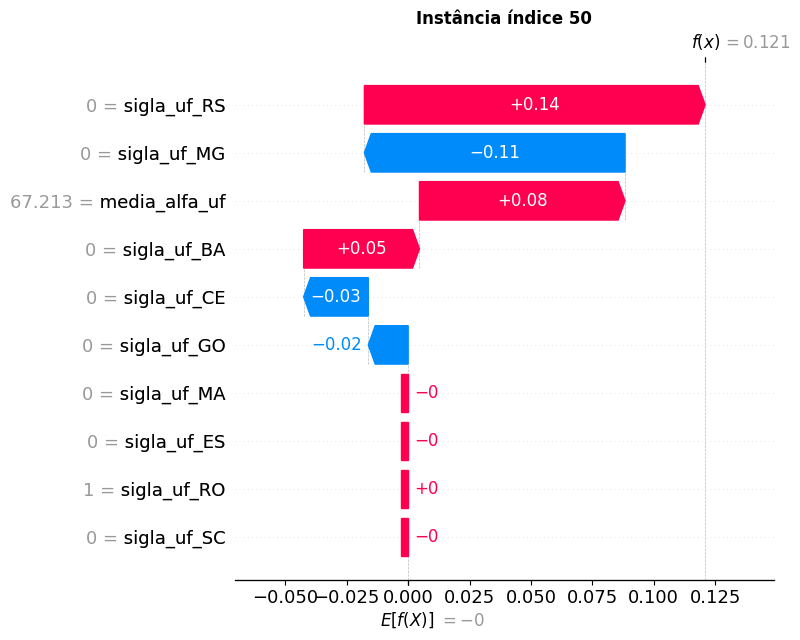

Decision plot


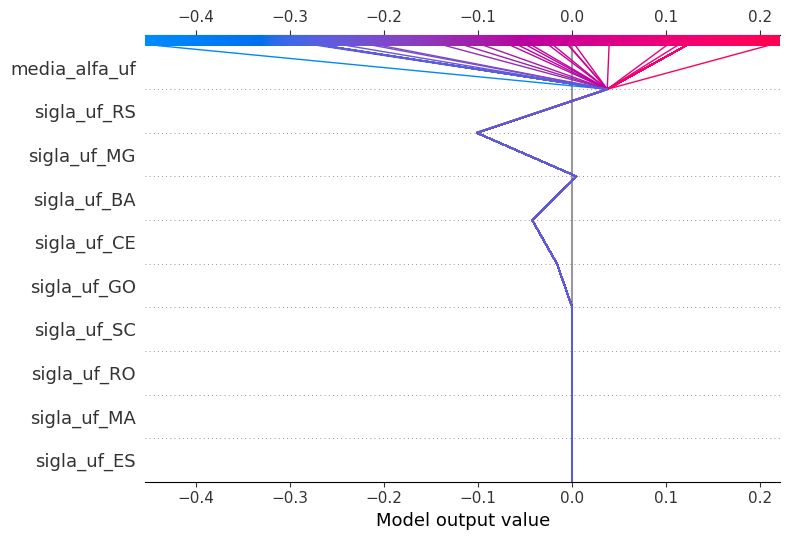

In [ ]:
# ===============================================================
# SHAP PARA EXPLICABILIDADE
# ===============================================================

# 1. Nomes das colunas selecionadas pelo SelectKBest
selected_cols = X_train.columns[selector.get_support()].tolist()

# 2. DataFrames
X_train_scaled_df = pd.DataFrame(X_train_selected, columns=selected_cols, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_selected, columns=selected_cols, index=X_test.index)

# 3. DataFrame RAW
X_test_raw_df = X_test[selected_cols].copy()

# 4. Instanciar o Explainer e gerar os SHAP values
modelo_final = melhor_modelo
masker = shap.maskers.Independent(X_train_scaled_df, max_samples=X_train_scaled_df.shape[0])
explainer = shap.LinearExplainer(modelo_final, masker)
explanation = explainer(X_test_scaled_df)

shap_values = explanation.values
expected_val = explainer.expected_value

# ===============================================================
# 5. VISÃO GLOBAL (Summary Plot)
# ===============================================================
print("Summary Plot (Beeswarm) - Valores Originais")
shap.summary_plot(shap_values, X_test_raw_df)

print("Summary Plot (Bar)")
shap.summary_plot(shap_values, X_test_raw_df, plot_type="bar")

# ===============================================================
# 6. DEPENDENCE PLOTS (Grid com as Top Features)
# ===============================================================
print("Dependence plots - Valores Originais")

# Seleciona as Top 6 variáveis com maior impacto médio absoluto
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_features = pd.Series(mean_abs_shap, index=selected_cols).sort_values(ascending=False).head(6).index

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feat in zip(axes.flatten(), top_features):
    shap.dependence_plot(
        feat,
        shap_values,
        X_test_raw_df,
        ax=ax,
        show=False
    )
    ax.set_title(f"Dependência: {feat}", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("dependence_grid_valores_reais.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# ===============================================================
# 7. WATERFALL PLOTS (Instâncias Individuais)
# ===============================================================
print("Waterfall plots - Valores Originais")

for idx in [0, 10, 50]:
    if idx < len(X_test_raw_df):
        exp_instance = shap.Explanation(
            values=shap_values[idx],
            base_values=expected_val,
            data=X_test_raw_df.iloc[idx].values,
            feature_names=selected_cols
        )

        plt.figure(figsize=(8, 6))
        shap.waterfall_plot(exp_instance, show=False)
        plt.title(f"Instância índice {idx}", fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.savefig(f"waterfall_idx_{idx}.png", dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()

# ===============================================================
# 8. DECISION PLOT
# ===============================================================
print("Decision plot")
n_samples = min(100, len(X_test_raw_df))

plt.figure(figsize=(10, 6))
shap.decision_plot(
    expected_val,
    shap_values[:n_samples],
    X_test_raw_df.iloc[:n_samples],
    show=False
)
plt.tight_layout()
plt.savefig("decision_plot.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()